<a href="https://colab.research.google.com/github/rrivasr12/Aprendizaje_de_Maquina/blob/master/analisis_s3f3_fase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc

In [15]:
df = pd.read_csv(Path("Clean_Dataset.csv"), sep=",", decimal=".")

In [16]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [17]:
# Completitud y consistencia
print(df.isnull().sum())
print('Duplicados:', df.duplicated().sum())
# Detección de outliers (IQR) en variables numéricas
for col in ['price', 'duration', 'days_left']:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: q1={q1} q3={q3} lower={lower:.2f} upper={upper:.2f} outliers={n_out} ({100*n_out/len(df):.2f}%)')

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64
Duplicados: 0
price: q1=4783.0 q3=42521.0 lower=-51824.00 upper=99128.00 outliers=123 (0.04%)
duration: q1=6.83 q3=16.17 lower=-7.18 upper=30.18 outliers=2110 (0.70%)
days_left: q1=15.0 q3=38.0 lower=-19.50 upper=72.50 outliers=0 (0.00%)


In [18]:
df[["duration", "days_left", "price"]].describe().round(2)

,duration,days_left,price
count,300153.00,300153.00,300153.00
mean,12.22,26.00,20889.66
std,7.19,13.56,22697.77
min,0.83,1.00,1105.00
25%,6.83,15.00,4783.00
50%,11.25,26.00,7425.00
75%,16.17,38.00,42521.00
max,49.83,49.00,123071.00


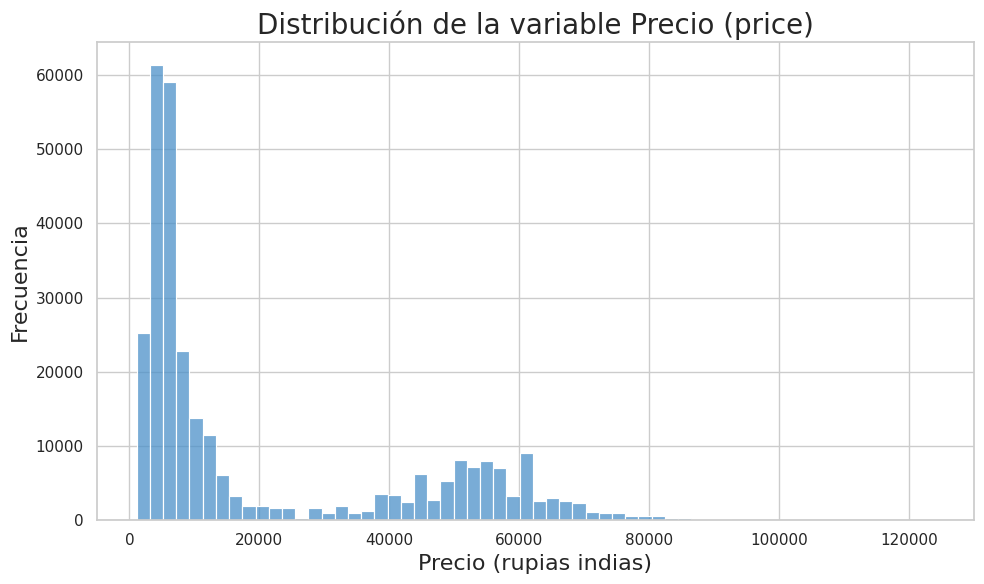

In [40]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df["price"],bins=60,color="#4C91C9",edgecolor="white")
plt.title("Distribución de la variable Precio (price)", fontsize=20)
plt.xlabel("Precio (rupias indias)", fontsize=16)
plt.ylabel("Frecuencia", fontsize=16)
plt.xlim(-5000, 130000)
plt.tight_layout()
plt.show()

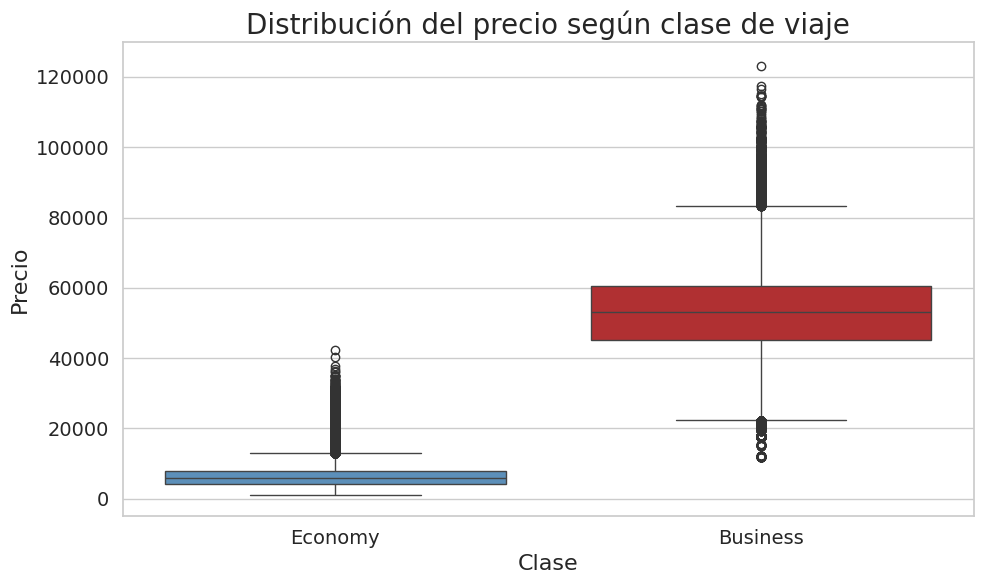

In [41]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df,x="class",y="price",order=["Economy", "Business"],hue="class",palette={"Economy": "#4C91C9","Business": "#C51B1D"},
    legend=False,
    flierprops={"marker": "o","markerfacecolor": "none","markeredgecolor": "#333333","markersize": 6,"linestyle": "none"})
plt.title("Distribución del precio según clase de viaje",fontsize=20)
plt.xlabel("Clase", fontsize=16)
plt.ylabel("Precio", fontsize=16)
plt.tick_params(axis="both", labelsize=14)
plt.ylim(-5000, 130000)
plt.tight_layout()
plt.show()

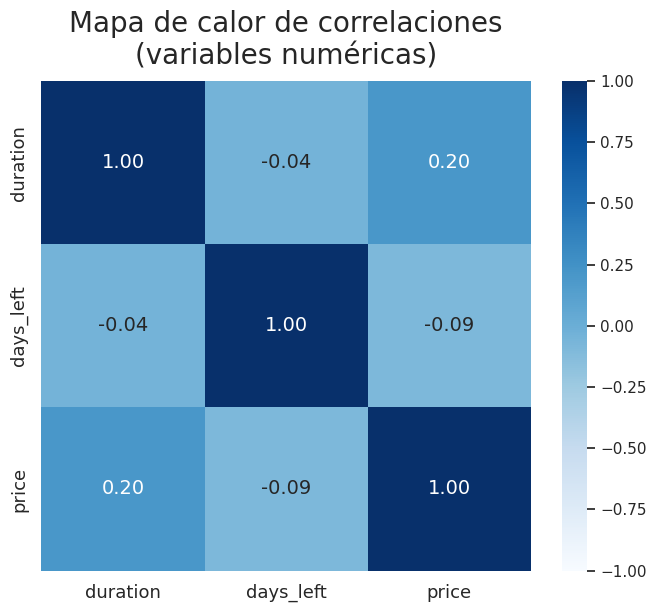

In [42]:
variables = ["duration", "days_left", "price"]
matriz_correlacion = df[variables].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(matriz_correlacion,annot=True,fmt=".2f",cmap="Blues",vmin=-1,vmax=1,square=True,annot_kws={"fontsize": 14},
    cbar_kws={"ticks":[-1, -0.75, -0.50, -0.25, 0, 0.25, 0.50, 0.75, 1]})
plt.title("Mapa de calor de correlaciones\n(variables numéricas)",fontsize=20,pad=12)
plt.xticks(rotation=0, fontsize=13)
plt.yticks(rotation=90, fontsize=13)
plt.tight_layout()
plt.show()

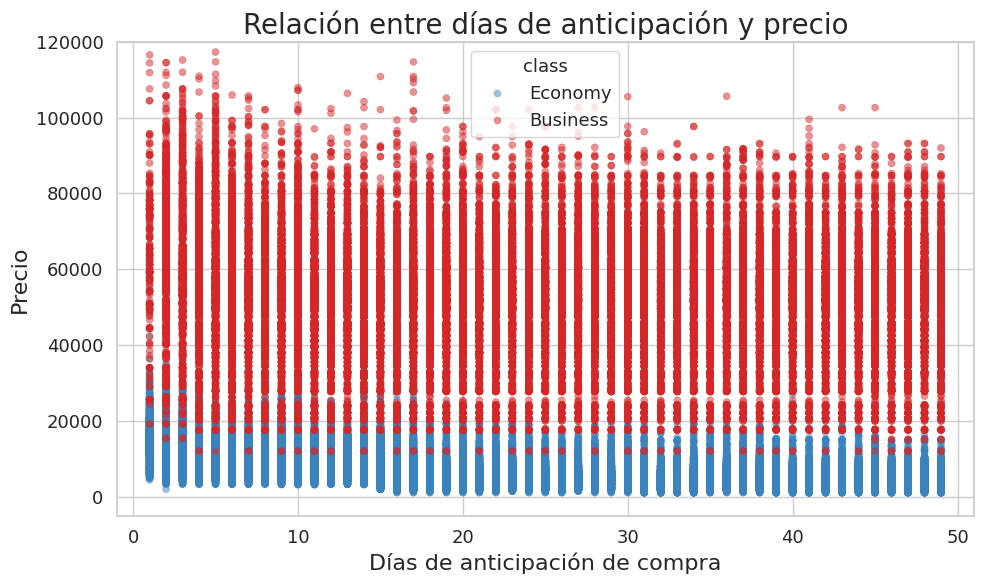

In [43]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,x="days_left",y="price",hue="class",hue_order=["Economy", "Business"],palette={"Economy": "#3B83BD","Business": "#D62728"},
    alpha=0.50,s=25,edgecolor=None)
plt.title("Relación entre días de anticipación y precio",fontsize=20)
plt.xlabel("Días de anticipación de compra", fontsize=16)
plt.ylabel("Precio", fontsize=16)
plt.xlim(-1, 51)
plt.ylim(-5000, 120000)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(title="class",loc="upper center",fontsize=13,title_fontsize=13)
plt.tight_layout()
plt.show()

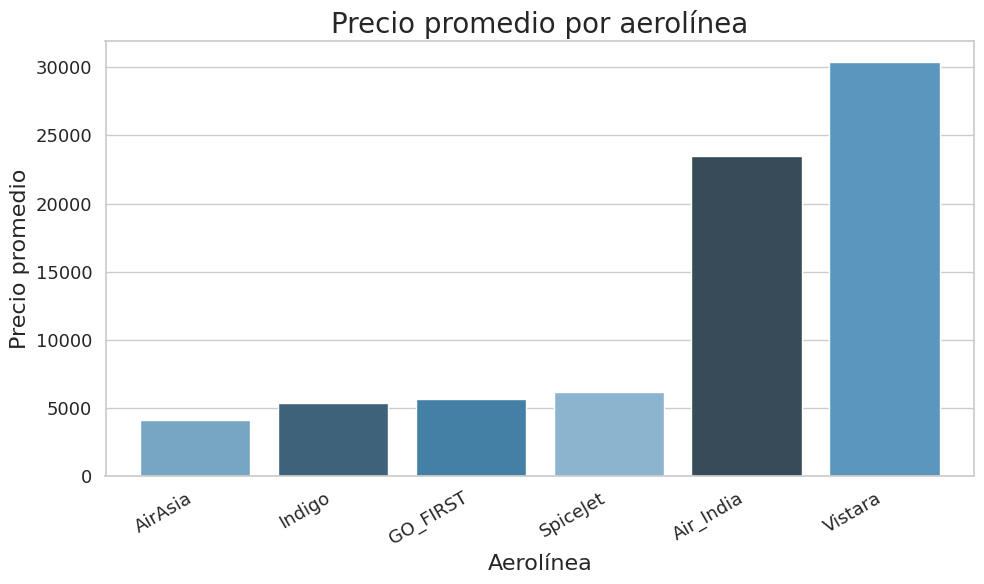

In [44]:
sns.set_theme(style="whitegrid")
precio_promedio = (df.groupby("airline")["price"].mean().sort_values())
colores = ["#77A6C5","#3E627A","#447FA6","#8DB4CF","#374B59","#5A96BE"]
ax = precio_promedio.plot(kind="bar",figsize=(10, 6),color=colores,edgecolor="white",width=0.8)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
plt.title("Precio promedio por aerolínea", fontsize=20)
plt.xlabel("Aerolínea", fontsize=16)
plt.ylabel("Precio promedio", fontsize=16)
plt.xticks(rotation=30, ha="right", fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
# Variables predictoras
cat_cols = ["airline","source_city","departure_time","stops","arrival_time","destination_city","class"]
num_cols = ["duration","days_left"]
X = df[cat_cols + num_cols]
y = df["price"]
# Partición 70 % entrenamiento / 30 % temporal - Se estratifica por class para conservar su distribución
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.30,random_state=42,stratify=X["class"])
# Dividir el 30 % temporal en: 15 % validación / 15 % prueba
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=42,stratify=X_temp["class"])
# Preprocesamiento
pre = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=True),cat_cols),
        ("num",StandardScaler(),num_cols)
    ],sparse_threshold=1.0)
# Ajustar exclusivamente con entrenamiento
X_train_enc = pre.fit_transform(X_train)
# Aplicar la transformación aprendida
X_val_enc = pre.transform(X_val)
X_test_enc = pre.transform(X_test)
print("Dataset completo:", X.shape)
print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)
print("Prueba:", X_test.shape, y_test.shape)
print("\nMatrices preprocesadas:")
print("X_train_enc:", X_train_enc.shape, type(X_train_enc))
print("X_val_enc:", X_val_enc.shape, type(X_val_enc))
print("X_test_enc:", X_test_enc.shape, type(X_test_enc))
print(f"Entrenamiento: {len(X_train) / len(X):.2%}")
print(f"Validación:    {len(X_val) / len(X):.2%}")
print(f"Prueba:        {len(X_test) / len(X):.2%}")
for nombre, datos in [
    ("Dataset completo", X),
    ("Entrenamiento", X_train),
    ("Validación", X_val),
    ("Prueba", X_test)
]:
    print(f"\n{nombre}")
    print(datos["class"].value_counts(normalize=True).round(4))
X_clf = df.drop(columns=["class", "price"])
y_clf = (df["class"] == "Business").astype(int)

Dataset completo: (300153, 9)
Entrenamiento: (210107, 9) (210107,)
Validación: (45023, 9) (45023,)
Prueba: (45023, 9) (45023,)

Matrices preprocesadas:
X_train_enc: (210107, 37) <class 'scipy.sparse._csr.csr_matrix'>
X_val_enc: (45023, 37) <class 'scipy.sparse._csr.csr_matrix'>
X_test_enc: (45023, 37) <class 'scipy.sparse._csr.csr_matrix'>
Entrenamiento: 70.00%
Validación:    15.00%
Prueba:        15.00%

Dataset completo
class
Economy     0.6885
Business    0.3115
Name: proportion, dtype: float64

Entrenamiento
class
Economy     0.6885
Business    0.3115
Name: proportion, dtype: float64

Validación
class
Economy     0.6885
Business    0.3115
Name: proportion, dtype: float64

Prueba
class
Economy     0.6885
Business    0.3115
Name: proportion, dtype: float64


In [34]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import (RandomForestRegressor,GradientBoostingRegressor)
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)

mlp = TransformedTargetRegressor(
    regressor=MLPRegressor(hidden_layer_sizes=(32, 16),max_iter=500,early_stopping=False,n_iter_no_change=20,random_state=42),
    transformer=StandardScaler())

modelos = {
    "Ridge": Ridge(alpha=1.0,solver="lsqr"),
    "Random Forest": RandomForestRegressor(n_estimators=30,max_depth=12,random_state=42,n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=40,max_depth=3,random_state=42),
    "MLP (proxy DL)": mlp
}

resultados_largos = []
modelos_ajustados = {}

for nombre, modelo in modelos.items():
    print(f"Entrenando: {nombre}")
    pipe = Pipeline([("pre", clone(pre)),("model", clone(modelo))])
    pipe.fit(X_train, y_train)   # Entrenar solamente con el 70 %
    modelos_ajustados[nombre] = pipe
    conjuntos = [("Entrenamiento", X_train, y_train),("Validación", X_val, y_val),("Test", X_test, y_test)]
    for conjunto, X_eval, y_eval in conjuntos:
        pred = pipe.predict(X_eval)
        resultados_largos.append({
            "Modelo": nombre,
            "Conjunto": conjunto,
            "RMSE": np.sqrt(mean_squared_error(y_eval, pred)),
            "MAE": mean_absolute_error(y_eval, pred),
            "R²": r2_score(y_eval, pred)
        })

metricas_df = pd.DataFrame(resultados_largos)
display(metricas_df.sort_values(["Conjunto", "RMSE"]).round(4))

Entrenando: Ridge
Entrenando: Random Forest
Entrenando: Gradient Boosting
Entrenando: MLP (proxy DL)


,Modelo,Conjunto,RMSE,MAE,R²
3,Random Forest,Entrenamiento,3828.9869,2066.0086,0.9715
9,MLP (proxy DL),Entrenamiento,3968.6622,2348.0130,0.9694
6,Gradient Boosting,Entrenamiento,5298.0468,3169.4315,0.9455
0,Ridge,Entrenamiento,6743.7496,4560.2447,0.9117
5,Random Forest,Test,3982.1290,2137.0457,0.9693
11,MLP (proxy DL),Test,4057.3159,2386.2797,0.9681
8,Gradient Boosting,Test,5293.5423,3155.1266,0.9457
2,Ridge,Test,6731.0613,4540.3930,0.9123
4,Random Forest,Validación,4001.1797,2158.1061,0.9689
10,MLP (proxy DL),Validación,4064.4039,2398.8937,0.9679


In [35]:
resultados_val = metricas_df[metricas_df["Conjunto"] == "Validación"].copy()
ranking_val = resultados_val.sort_values(by=["RMSE", "MAE", "R²"],ascending=[True, True, False])
display(ranking_val.round(4))
mejor_fila = ranking_val.iloc[0]
mejor_nombre = mejor_fila["Modelo"]
print("Mejor modelo:", mejor_nombre)
print("RMSE validación:", round(mejor_fila["RMSE"], 4))
print("MAE validación:", round(mejor_fila["MAE"], 4))
print("R² validación:", round(mejor_fila["R²"], 4))

,Modelo,Conjunto,RMSE,MAE,R²
4,Random Forest,Validación,4001.1797,2158.1061,0.9689
10,MLP (proxy DL),Validación,4064.4039,2398.8937,0.9679
7,Gradient Boosting,Validación,5338.3910,3192.9104,0.9446
1,Ridge,Validación,6825.0581,4613.2556,0.9095


Mejor modelo: Random Forest
RMSE validación: 4001.1797
MAE validación: 2158.1061
R² validación: 0.9689


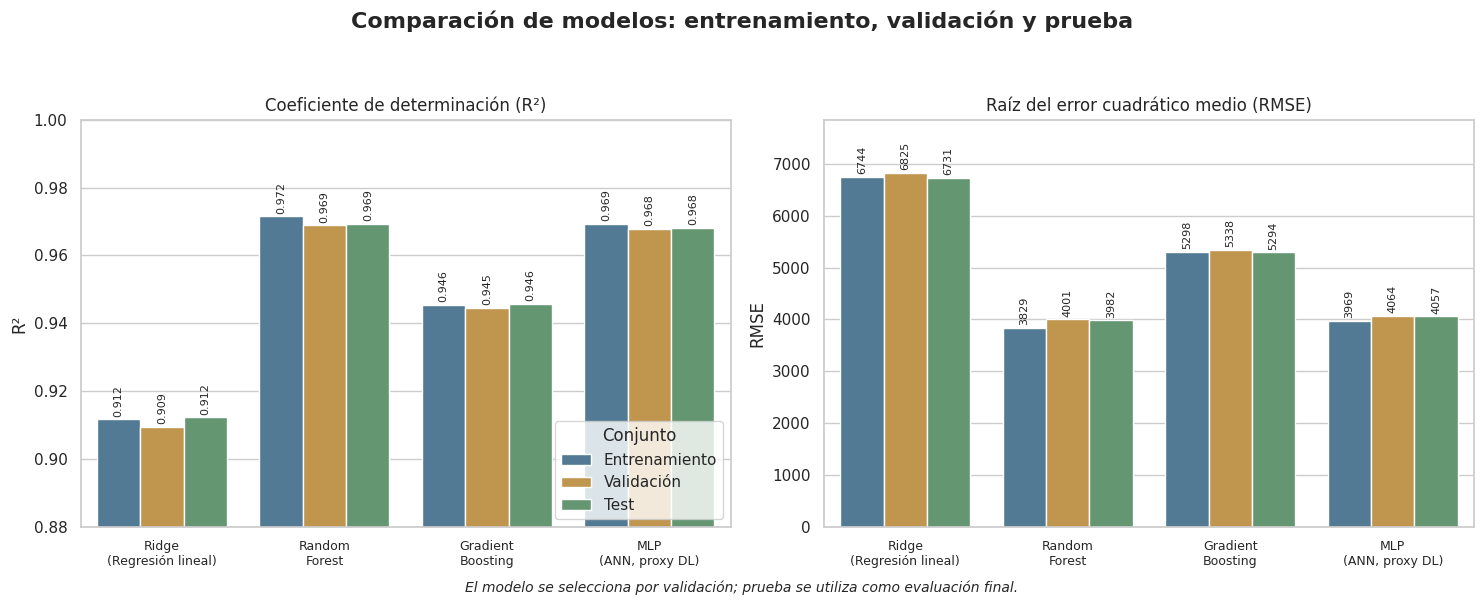

In [45]:
sns.set_theme(style="whitegrid")
orden = ["Ridge","Random Forest","Gradient Boosting","MLP (proxy DL)"]
etiquetas_modelos = {"Ridge": "Ridge\n(Regresión lineal)","Random Forest": "Random\nForest","Gradient Boosting": "Gradient\nBoosting","MLP (proxy DL)": "MLP\n(ANN, proxy DL)"}
orden_conjuntos = ["Entrenamiento","Validación","Test"]
comparacion = metricas_df.copy()
comparacion["Conjunto"] = comparacion["Conjunto"].replace({"Train": "Entrenamiento","Validation": "Validación","Prueba": "Test"})
comparacion = comparacion[comparacion["Modelo"].isin(orden) & comparacion["Conjunto"].isin(orden_conjuntos)].copy()
comparacion["Etiqueta"] = comparacion["Modelo"].map(etiquetas_modelos)
comparacion["Modelo"] = pd.Categorical(comparacion["Modelo"],categories=orden,ordered=True)
comparacion = comparacion.sort_values(["Modelo", "Conjunto"])
paleta = {"Entrenamiento": "#477D9F","Validación": "#D39A3B","Test": "#5C9E6E"}
fig, axes = plt.subplots(1,2,figsize=(15, 6))
fig.suptitle("Comparación de modelos: entrenamiento, validación y prueba",fontsize=16,fontweight="bold")
# R²
sns.barplot(data=comparacion,x="Etiqueta",y="R²",hue="Conjunto",hue_order=orden_conjuntos,palette=paleta,errorbar=None,ax=axes[0])
axes[0].set_title("Coeficiente de determinación (R²)")
axes[0].set_xlabel("")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0.88, 1.00)
axes[0].grid(axis="x", visible=False)
axes[0].tick_params(axis="x", labelsize=9)
for contenedor in axes[0].containers:
    axes[0].bar_label(contenedor,fmt="%.3f",padding=2,fontsize=8,rotation=90)
axes[0].legend(title="Conjunto",loc="lower right")
# RMSE
sns.barplot(data=comparacion,x="Etiqueta",y="RMSE",hue="Conjunto",hue_order=orden_conjuntos,palette=paleta,errorbar=None,ax=axes[1])
axes[1].set_title("Raíz del error cuadrático medio (RMSE)")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE")
axes[1].set_ylim(0,comparacion["RMSE"].max() * 1.15)
axes[1].grid(axis="x", visible=False)
axes[1].tick_params(axis="x", labelsize=9)
for contenedor in axes[1].containers:
    axes[1].bar_label(contenedor,fmt="%.0f",padding=2,fontsize=8,rotation=90)
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()
plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.figtext(0.5,0.01,"El modelo se selecciona por validación; prueba se utiliza como evaluación final.",ha="center",fontsize=10,style="italic")
plt.show()

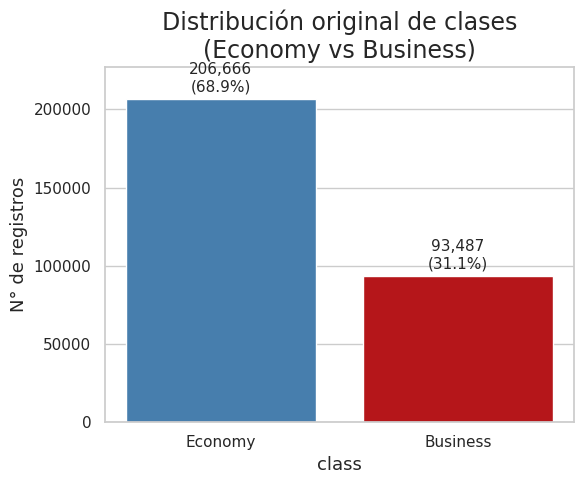

In [46]:
sns.set_theme(style="whitegrid")
orden = ["Economy", "Business"]
conteo = (df["class"].value_counts().reindex(orden))
porcentaje = conteo / conteo.sum() * 100
fig, ax = plt.subplots(figsize=(6, 5))
barras = ax.bar(conteo.index,conteo.values,color=["#477EAD", "#B5161A"],edgecolor="white",width=0.8)
ax.bar_label(barras,labels=[f"{cantidad:,.0f}\n({porc:.1f}%)" for cantidad, porc in zip(conteo, porcentaje)],padding=3,fontsize=11)
ax.set_title("Distribución original de clases\n(Economy vs Business)",fontsize=17)
ax.set_xlabel("class", fontsize=13)
ax.set_ylabel("N° de registros", fontsize=13)
ax.set_ylim(0, conteo.max() * 1.10)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

In [65]:
from sklearn.model_selection import train_test_split
df_clas = df.drop(columns=["Unnamed: 0"], errors="ignore")
variables_clasificacion = ["airline","source_city","departure_time","stops","arrival_time","destination_city","duration","days_left"]
X_clf = df_clas[variables_clasificacion].copy()
#X_clf = df_clas.drop(columns=["class"])  # Predictores: todas las variables excepto class
y_clf = (df_clas["class"] == "Business").astype(int) # Objetivo auxiliar: 0 = Economy, 1 = Business
X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = (train_test_split(X_clf,y_clf,test_size=0.30,random_state=42,stratify=y_clf)) # 70 % entrenamiento y 30 % temporal
X_val_clf, X_test_clf, y_val_clf, y_test_clf = (train_test_split(X_temp_clf,y_temp_clf,test_size=0.50,random_state=42,stratify=y_temp_clf)) # 15 % validación y 15 % prueba
print("Entrenamiento:")
print(y_train_clf.value_counts().sort_index())
print("\nValidación:")
print(y_val_clf.value_counts().sort_index())
print("\nPrueba:")
print(y_test_clf.value_counts().sort_index())

Entrenamiento:
class
0    144666
1     65441
Name: count, dtype: int64

Validación:
class
0    31000
1    14023
Name: count, dtype: int64

Prueba:
class
0    31000
1    14023
Name: count, dtype: int64


In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

columnas_numericas = (X_train_clf.select_dtypes(include="number").columns.tolist())
columnas_categoricas = (X_train_clf.select_dtypes(exclude="number").columns.tolist())
pre_num = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
pre_cat = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore",sparse_output=True))])
pre_clf = ColumnTransformer(transformers=[("num", pre_num, columnas_numericas),("cat", pre_cat, columnas_categoricas)],sparse_threshold=1.0)
X_train_enc = pre_clf.fit_transform(X_train_clf)  # Ajustar solamente con entrenamiento
X_val_enc = pre_clf.transform(X_val_clf)  # Aplicar a validación y prueba
X_test_enc = pre_clf.transform(X_test_clf)

print("Train:", X_train_enc.shape, type(X_train_enc))
print("Val:  ", X_val_enc.shape, type(X_val_enc))
print("Test: ", X_test_enc.shape, type(X_test_enc))

Train: (210107, 35) <class 'scipy.sparse._csr.csr_matrix'>
Val:   (45023, 35) <class 'scipy.sparse._csr.csr_matrix'>
Test:  (45023, 35) <class 'scipy.sparse._csr.csr_matrix'>


In [62]:
from collections import Counter
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

modelo_base = LogisticRegression(solver="saga",max_iter=500,tol=1e-3,random_state=42)
tecnicas = {
    "Sin balanceo (original)": None,
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "Random Oversampling": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42, k_neighbors=5)
}
resultados_balanceo = []
for nombre, balanceador in tecnicas.items():
    print(f"Procesando: {nombre}")
    if balanceador is None:  # Balancear exclusivamente entrenamiento
        X_res = X_train_enc
        y_res = y_train_clf
    else:
        X_res, y_res = balanceador.fit_resample(X_train_enc,y_train_clf)
    cantidades = Counter(y_res)
    modelo = clone(modelo_base)
    modelo.fit(X_res, y_res)
    y_pred_val = modelo.predict(X_val_enc) # Evaluación sobre validación sin balancear
    resultados_balanceo.append({
        "Técnica": nombre,
        "N° Economy / Business":f"{cantidades.get(0, 0)} / "f"{cantidades.get(1, 0)}",
        "Precisión (Business)": precision_score(y_val_clf,y_pred_val,pos_label=1,zero_division=0),
        "Recall (Business)": recall_score(y_val_clf,y_pred_val,pos_label=1,zero_division=0),
        "F1 (Business)": f1_score(y_val_clf,y_pred_val,pos_label=1,zero_division=0)
    })
    del modelo, y_pred_val  # Liberar memoria antes de la siguiente técnica
    if balanceador is not None:
        del X_res, y_res
    gc.collect()

Procesando: Sin balanceo (original)
Procesando: Random Undersampling
Procesando: Random Oversampling
Procesando: SMOTE


In [63]:
tabla_balanceo = pd.DataFrame(resultados_balanceo)
columnas_metricas = ["Precisión (Business)","Recall (Business)","F1 (Business)"]
tabla_balanceo[columnas_metricas] = (tabla_balanceo[columnas_metricas].round(3))
ranking_balanceo = tabla_balanceo.sort_values(by=["F1 (Business)","Recall (Business)","Precisión (Business)"],ascending=[False, False, False])
display(ranking_balanceo)
mejor_tecnica = ranking_balanceo.iloc[0]
print("Técnica seleccionada:", mejor_tecnica["Técnica"])
print("F1 validación:", mejor_tecnica["F1 (Business)"])

,Técnica,N° Economy / Business,Precisión (Business),Recall (Business),F1 (Business)
1,Random Undersampling,65441 / 65441,0.464,0.988,0.631
2,Random Oversampling,144666 / 144666,0.464,0.988,0.631
3,SMOTE,144666 / 144666,0.464,0.988,0.631
0,Sin balanceo (original),144666 / 65441,0.503,0.288,0.367


Técnica seleccionada: Random Undersampling
F1 validación: 0.631


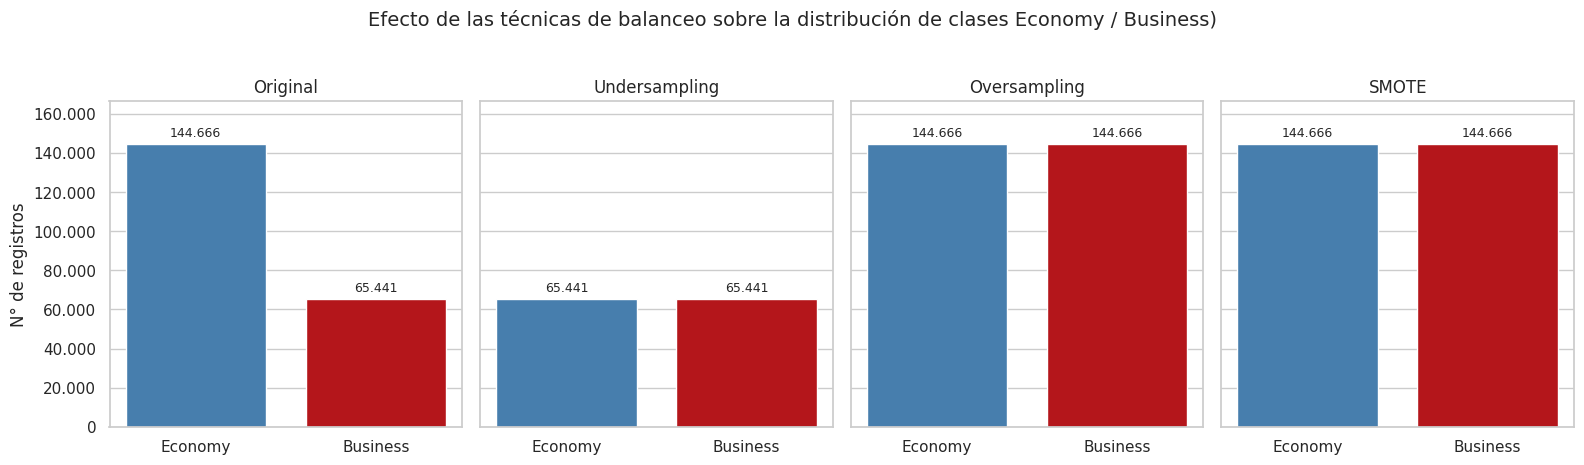

In [64]:
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")
conteos_originales = (y_train_clf.value_counts().sort_index())
n_economy = int(conteos_originales.get(0, 0))
n_business = int(conteos_originales.get(1, 0))
n_mayoritaria = max(n_economy, n_business)
n_minoritaria = min(n_economy, n_business)
distribuciones = {
    "Original": [n_economy,n_business],
    "Undersampling": [n_minoritaria,n_minoritaria],
    "Oversampling": [n_mayoritaria,n_mayoritaria],
    "SMOTE": [n_mayoritaria,n_mayoritaria]
}
clases = ["Economy", "Business"]
colores = ["#477EAD", "#B4161B"]
fig, axes = plt.subplots(1,4,figsize=(16, 4.5),sharey=True)
fig.suptitle("Efecto de las técnicas de balanceo sobre la distribución de clases Economy / Business)",fontsize=14,y=1.03)
for ax, (tecnica, cantidades) in zip(axes,distribuciones.items()):
    barras = ax.bar(clases,cantidades,color=colores,edgecolor="white",width=0.78)
    ax.set_title(tecnica, fontsize=12)
    ax.set_xlabel("")
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.bar_label(barras,
        labels=[
            f"{cantidad:,}".replace(",", ".")
            for cantidad in cantidades
        ],
        padding=3,
        fontsize=9)
axes[0].set_ylabel("N° de registros")
formato_miles = FuncFormatter(lambda valor, posicion:f"{int(valor):,}".replace(",", "."))
axes[0].yaxis.set_major_formatter(formato_miles)
limite_superior = max(n_mayoritaria, n_economy) * 1.15
axes[0].set_ylim(0, limite_superior)
plt.tight_layout()
plt.savefig("distribucion_balanceo.png",dpi=300,bbox_inches="tight")
plt.show()